# Dog vs Cat Classification - 01: EDA

The classic binary image task: is it a dog or a cat? Dataset: HuggingFace `Bingsu/Cat_and_Dog`. A committed 64x64 sample sits under `data/sample/<class>/`.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', len(classes)); print(classes)
print('total images:', len(imgs))

classes: 2
['cat', 'dog']
total images: 1000


## 1. Class balance

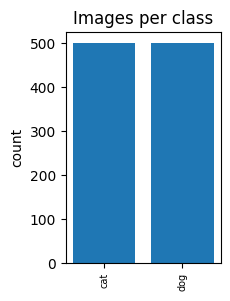

cat                    500
dog                    500


In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(min(14,1+len(classes)*0.5),3)); plt.bar(range(len(classes)), [cnt[c] for c in classes])
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=7); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-22s %d' % (k, cnt[k]))

## 2. One sample per class

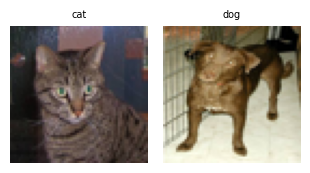

In [3]:
import math
n=len(classes); cols=min(n,10); rows=math.ceil(n/cols)
fig, ax = plt.subplots(rows, cols, figsize=(1.6*cols, 1.8*rows)); ax=np.atleast_2d(ax)
seen={}
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen[l]=im
for i,cl in enumerate(classes):
    a=ax[i//cols][i%cols]; a.imshow(seen[cl]); a.set_title(cl, fontsize=7); a.axis('off')
for j in range(n, rows*cols): ax[j//cols][j%cols].axis('off')
plt.tight_layout(); plt.show()

### Findings
Two balanced classes of natural pet photos with varied breeds, poses, and backgrounds.